In [26]:
import pandas as pd

In [27]:
import numpy as np

In [28]:
df=pd.read_csv('student-mat.csv')

In [29]:
df.head()

,school,sex,age,address,famsize,Parrent_status,Mother_edu,Father_edu,Mother_job,Father_job,...,Family_quality_reln,freetime_after_school,goout_with_friends,workday_alcohol_consum,weekend_alcohol_consum,health_status,absences,G1,G2,G3
0,GP,F,18,U,GT3,A,4,4,at_home,teacher,...,4,3,4,1,1,3,6,5,6,6
1,GP,F,17,U,GT3,T,1,1,at_home,other,...,5,3,3,1,1,3,4,5,5,6
2,GP,F,15,U,LE3,T,1,1,at_home,other,...,4,3,2,2,3,3,10,7,8,10
3,GP,F,15,U,GT3,T,4,2,health,services,...,3,2,2,1,1,5,2,15,14,15
4,GP,F,16,U,GT3,T,3,3,other,other,...,4,3,2,1,2,5,4,6,10,10


In [30]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 395 entries, 0 to 394
Data columns (total 33 columns):
 #   Column                    Non-Null Count  Dtype 
---  ------                    --------------  ----- 
 0   school                    395 non-null    object
 1   sex                       395 non-null    object
 2   age                       395 non-null    int64 
 3   address                   395 non-null    object
 4   famsize                   395 non-null    object
 5   Parrent_status            395 non-null    object
 6   Mother_edu                395 non-null    int64 
 7   Father_edu                395 non-null    int64 
 8   Mother_job                395 non-null    object
 9   Father_job                395 non-null    object
 10  reason_to_chose_school    395 non-null    object
 11  guardian                  395 non-null    object
 12  traveltime                395 non-null    int64 
 13  weekly_studytime          395 non-null    int64 
 14  failures                  

In [31]:
df.isnull().sum()

,0
school,0
sex,0
age,0
address,0
famsize,0
Parrent_status,0
Mother_edu,0
Father_edu,0
Mother_job,0
Father_job,0


In [32]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import ipywidgets as widgets
from ipywidgets import interact

# 1. Establish static reference scales across the whole dataset
health_ticks = sorted(df['health_status'].unique())
min_h, max_h = min(health_ticks), max(health_ticks)
global_counts = df['health_status'].value_counts().reindex(health_ticks, fill_value=0)

# 2. Corrected Plotting Function for True Synchronization
def plot_synchronized_dashboard(health_range):
    fig, (ax_lines, ax_bars) = plt.subplots(1, 2, figsize=(12, 5))
    low, high = health_range

    # FILTER A: Active cohort chosen by user slider
    active_df = df[(df['health_status'] >= low) & (df['health_status'] <= high)]

    # Calculate grade averages *only* for the selected cohort
    # We group by health_status to split the multi-series lines across categories
    grouped = active_df.groupby('health_status')[['G1', 'G2']].mean().reindex(health_ticks)

    # --- Chart 1: True Multi-Series Synchronized Line Chart ---
    # Plots separate series with distinct colors and shapes
    ax_lines.plot(health_ticks, grouped['G1'], marker='o', markersize=8,
                  color='#1f77b4', linewidth=3, label='G1 Term Average')
    ax_lines.plot(health_ticks, grouped['G2'], marker='s', markersize=8,
                  color='#ff7f0e', linewidth=3, label='G2 Term Average')

    # Set titles dynamically based on your filter selection
    ax_lines.set_title(f'Cohort Grade Averages (Health {low} to {high})', fontsize=12, fontweight='bold')
    ax_lines.set_xlabel('Health Status Scale (1=Bad → 5=Good)')
    ax_lines.set_ylabel('Score Scale (0-20)')
    ax_lines.set_xticks(health_ticks)
    ax_lines.set_ylim(0, 20)
    ax_lines.grid(True, linestyle='--', alpha=0.5)
    ax_lines.legend(loc='lower left', frameon=True)

    # --- Chart 2: Synchronized Interactive Bar Highlight ---
    # Highlights selected health categories in blue, sets omitted profiles to light gray
    bar_colors = ['#1f77b4' if low <= h <= high else '#e2e2e2' for h in health_ticks]

    ax_bars.bar(health_ticks, global_counts, color=bar_colors, edgecolor='#444444', alpha=0.85, width=0.55)
    ax_bars.set_title('Cohort Distribution Profile', fontsize=12, fontweight='bold')
    ax_bars.set_xlabel('Health Status Groups')
    ax_bars.set_ylabel('Number of Students')
    ax_bars.set_xticks(health_ticks)
    ax_bars.grid(axis='y', linestyle=':', alpha=0.5)

    plt.tight_layout()
    plt.show()

# 3. Widget Controller setup
sync_slider = widgets.IntRangeSlider(
    value=[min_h, max_h],
    min=min_h,
    max=max_h,
    step=1,
    description='Sync Filter:',
    continuous_update=False,
    style={'description_width': 'initial'}
)

# 4. Run the interactive cell frame
interact(plot_synchronized_dashboard, health_range=sync_slider);

interactive(children=(IntRangeSlider(value=(1, 5), continuous_update=False, description='Sync Filter:', max=5,…

In [33]:
import altair as alt

# 1. This creates a true synchronized "brush" selector
brush = alt.selection_interval(resolve='global', encodings=['x'])

# 2. Multi-Series Line Chart (Responding to the Brush)
lines = alt.Chart(df).transform_fold(
    ['G1', 'G2'],
    as_=['Period', 'Grade']
).mark_line(point=True, strokeWidth=3).encode(
    x=alt.X('health_status:O', title='Health Status (1-5)'),
    y=alt.Y('mean(Grade):Q', title='Average Score (0-20)', scale=alt.Scale(domain=[0, 20])),
    color=alt.Color('Period:N', title='Series Line', scale=alt.Scale(scheme='category10'))
).transform_filter(
    brush  # Truly synchronized: filters dynamically when you drag on the bar chart
).properties(
    width=350,
    height=300,
    title='Synchronized Grade Averages'
)

# 3. Bar Chart acting as the Interactive Controller
bars = alt.Chart(df).mark_bar().encode(
    x=alt.X('health_status:O', title='Click & Drag Here to Filter Lines'),
    y=alt.Y('count():Q', title='Number of Students'),
    color=alt.condition(brush, alt.value('#1f77b4'), alt.value('lightgray'))
).add_params(
    brush  # Attaches the synchronized selector here
).properties(
    width=250,
    height=300,
    title='Student Health Distribution'
)

# 4. Display them side-by-side
lines | bars

alt.HConcatChart(...)

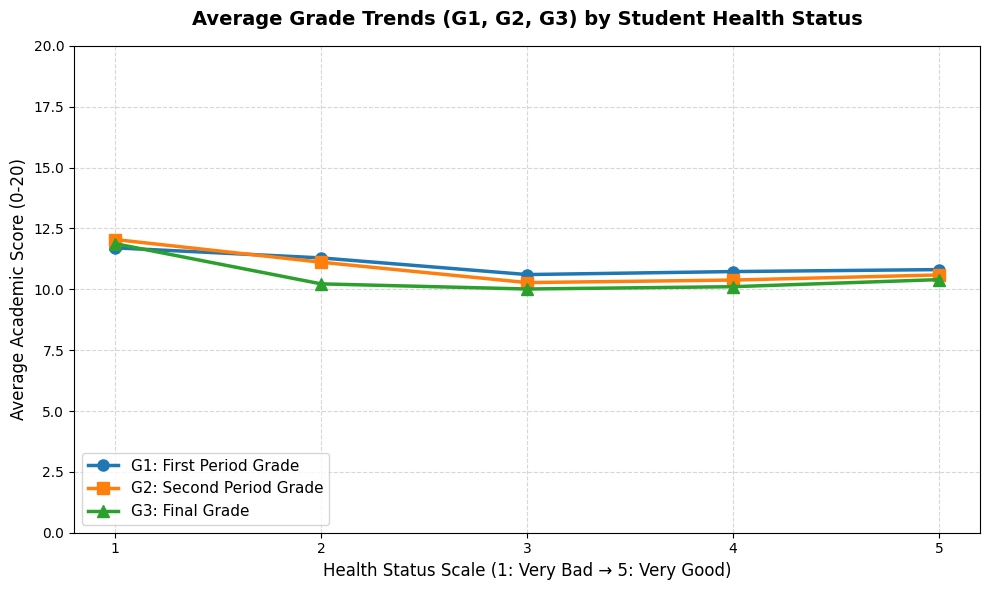

In [35]:
import matplotlib.pyplot as plt

# 1. Group the dataset by health_status and calculate the mean for all three grade periods
grouped_df = df.groupby('health_status')[['G1', 'G2', 'G3']].mean()

# 2. Create a single plot frame
plt.figure(figsize=(10, 6))

# 3. Plot each period explicitly with distinct markers and colors
plt.plot(grouped_df.index, grouped_df['G1'], marker='o', markersize=8,
         linewidth=2.5, label='G1: First Period Grade', color='#1f77b4')

plt.plot(grouped_df.index, grouped_df['G2'], marker='s', markersize=8,
         linewidth=2.5, label='G2: Second Period Grade', color='#ff7f0e')

plt.plot(grouped_df.index, grouped_df['G3'], marker='^', markersize=8,
         linewidth=2.5, label='G3: Final Grade', color='#2ca02c')

# 4. Add titles, labels, and clean axis formatting
plt.title('Average Grade Trends (G1, G2, G3) by Student Health Status', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Health Status Scale (1: Very Bad → 5: Very Good)', fontsize=12)
plt.ylabel('Average Academic Score (0-20)', fontsize=12)

# Ensure the axes align perfectly with the dataset limits
plt.xticks(grouped_df.index)   # Forces 1, 2, 3, 4, 5 x-ticks
plt.ylim(0, 20)                  # Sets vertical limits to match the 0-20 grade scale
plt.grid(True, linestyle='--', alpha=0.5)

# 5. Display the legend to track the multiple lines clearly
plt.legend(loc='lower left', frameon=True, fontsize=11)

# Render the single multi-line graph
plt.tight_layout()
plt.show()

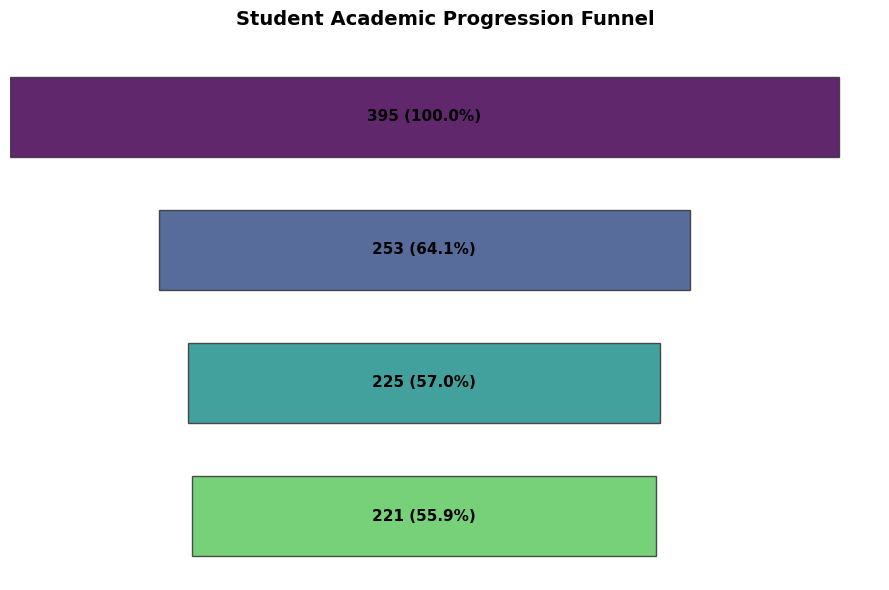

In [36]:
# 1. Calculate the sequential stages from your student dataset
total_students = len(df)
passed_g1 = len(df[df['G1'] >= 10])
passed_g2 = len(df[(df['G1'] >= 10) & (df['G2'] >= 10)])
passed_g3 = len(df[(df['G1'] >= 10) & (df['G2'] >= 10) & (df['G3'] >= 10)])

stages = ['Total Enrolled', 'Passed G1 (≥10)', 'Maintained Pass in G2', 'Final Pass (G3)']
counts = [total_students, passed_g1, passed_g2, passed_g3]

# 2. Set up the plot
fig, ax = plt.subplots(figsize=(9, 6))

# We use the total student count as the maximum width baseline to center everything
max_width = total_students

# 3. Plot each stage as a centered horizontal bar
for i, (stage, count) in enumerate(zip(stages, counts)):
    # Calculate the left offset to keep the bar perfectly centered
    left_offset = (max_width - count) / 2

    # Draw the bar
    bar = ax.barh(stage, count, left=left_offset, color=plt.cm.viridis(i / len(stages)),
                 edgecolor='#333333', alpha=0.85, height=0.6)

    # Calculate percentages relative to the initial starting cohort
    pct_of_total = (count / total_students) * 100

    # Add text labels inside or next to the funnel sections
    ax.text(max_width / 2, stage, f"{count} ({pct_of_total:.1f}%)",
            ha='center', va='center', color='black', fontweight='bold', fontsize=11)

# 4. Styling and cleanup
ax.set_title('Student Academic Progression Funnel', fontsize=14, fontweight='bold', pad=20)
ax.invert_yaxis()  # Puts the largest stage (Total Enrolled) at the top
ax.axis('off')     # Removes the background grid/axes to give it a clean funnel appearance

plt.tight_layout()
plt.show()

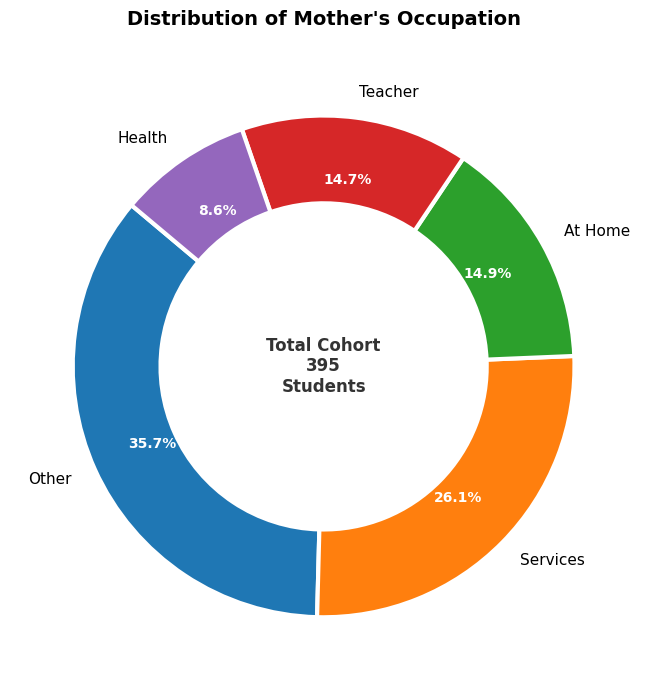

In [37]:
# 1. Aggregate the categorical data (e.g., Mother's Occupation distribution)
job_counts = df['Mother_job'].value_counts()
labels = job_counts.index.str.replace('_', ' ').str.title()  # Clean up labels (e.g., 'at_home' -> 'At Home')
values = job_counts.values

# 2. Set up clean, modern colors matching your previous dashboard theme
colors = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728', '#9467bd']

# 3. Build the Doughnut Chart
fig, ax = plt.subplots(figsize=(7, 7))

wedges, texts, autotexts = ax.pie(
    values,
    labels=labels,
    autopct='%1.1f%%',
    startangle=140,
    colors=colors,
    pctdistance=0.75,                                      # Positions percentages inside segments
    wedgeprops=dict(width=0.35, edgecolor='white', lw=3)  # 'width' defines the thickness, creating the center hole
)

# 4. Style text annotations inside and around the doughnut ring
plt.setp(autotexts, size=10, weight="bold", color="white")
plt.setp(texts, size=11, fontweight="medium")

# 5. Add a central summary label inside the hole
total_students = len(df)
ax.text(0, 0, f'Total Cohort\n{total_students}\nStudents',
        ha='center', va='center', fontsize=12, fontweight='bold', color='#333333')

# 6. Title and Layout Optimization
ax.set_title("Distribution of Mother's Occupation", fontsize=14, fontweight='bold', pad=20)
plt.tight_layout()
plt.show()

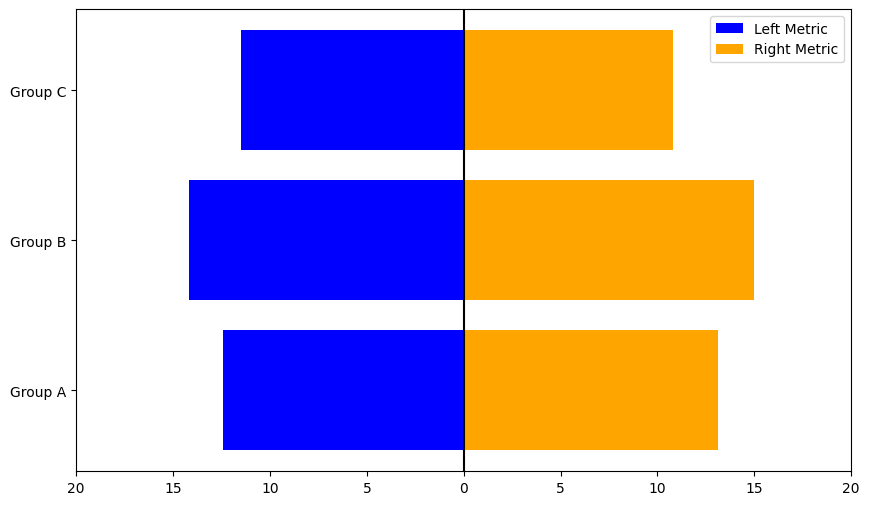

In [38]:
import matplotlib.pyplot as plt
import numpy as np

# 1. Prepare your data arrays
categories = ['Group A', 'Group B', 'Group C']
left_metrics = [12.4, 14.2, 11.5]   # e.g., G1 averages
right_metrics = [13.1, 15.0, 10.8]  # e.g., G2 averages
y_pos = np.arange(len(categories))

fig, ax = plt.subplots(figsize=(10, 6))

# 2. Draw Left Wing (Negative X) & Right Wing (Positive X)
ax.barh(y_pos, [-x for x in left_metrics], color='blue', label='Left Metric')
ax.barh(y_pos, right_metrics, color='orange', label='Right Metric')

# 3. Add the vertical center spine
ax.axvline(0, color='black', linewidth=1.5)

# 4. CRITICAL: Clean the X-Axis ticks so they don't show negative signs (-)
# Get the current tick locations, convert them to absolute (positive) integers
ax.set_xticks(ax.get_xticks())
ax.set_xticklabels([str(abs(int(x))) for x in ax.get_xticks()])

# 5. Map your category names to the Y-axis
ax.set_yticks(y_pos)
ax.set_yticklabels(categories)

plt.legend()
plt.show()

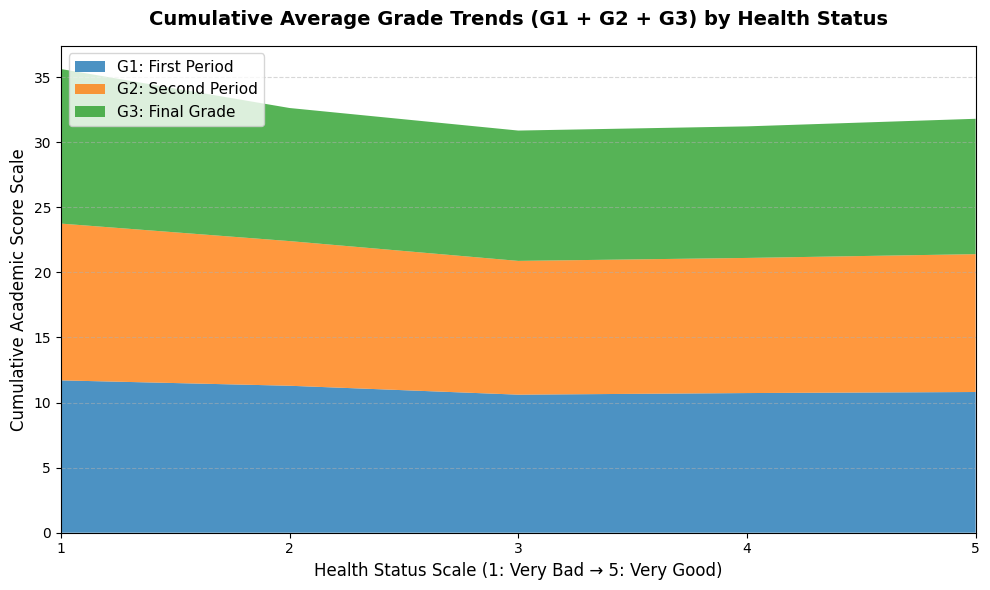

In [39]:
# 1. Group by health status and calculate the mean for G1, G2, and G3 periods
grouped_df = df.groupby('health_status')[['G1', 'G2', 'G3']].mean()

# Extract x (the independent variable) and y lines (the areas to stack)
x = grouped_df.index
y1 = grouped_df['G1']
y2 = grouped_df['G2']
y3 = grouped_df['G3']

# 2. Set up the plot frame
fig, ax = plt.subplots(figsize=(10, 6))

# 3. Create the Stacked Area Chart using stackplot
# We define clean colors matching your existing notebook palette
ax.stackplot(x, y1, y2, y3,
             labels=['G1: First Period', 'G2: Second Period', 'G3: Final Grade'],
             colors=['#1f77b4', '#ff7f0e', '#2ca02c'],
             alpha=0.8)

# 4. Add titles, labels, and clean axis formatting
ax.set_title('Cumulative Average Grade Trends (G1 + G2 + G3) by Health Status',
             fontsize=14, fontweight='bold', pad=15)
ax.set_xlabel('Health Status Scale (1: Very Bad → 5: Very Good)', fontsize=12)
ax.set_ylabel('Cumulative Academic Score Scale', fontsize=12)

# Ensure the x-axis aligns perfectly with your dataset integers
ax.set_xticks(x)
ax.set_xlim(min(x), max(x))

# 5. Add a clean grid and legend
ax.grid(axis='y', linestyle='--', alpha=0.5)
ax.legend(loc='upper left', frameon=True, fontsize=11)

plt.tight_layout()
plt.show()

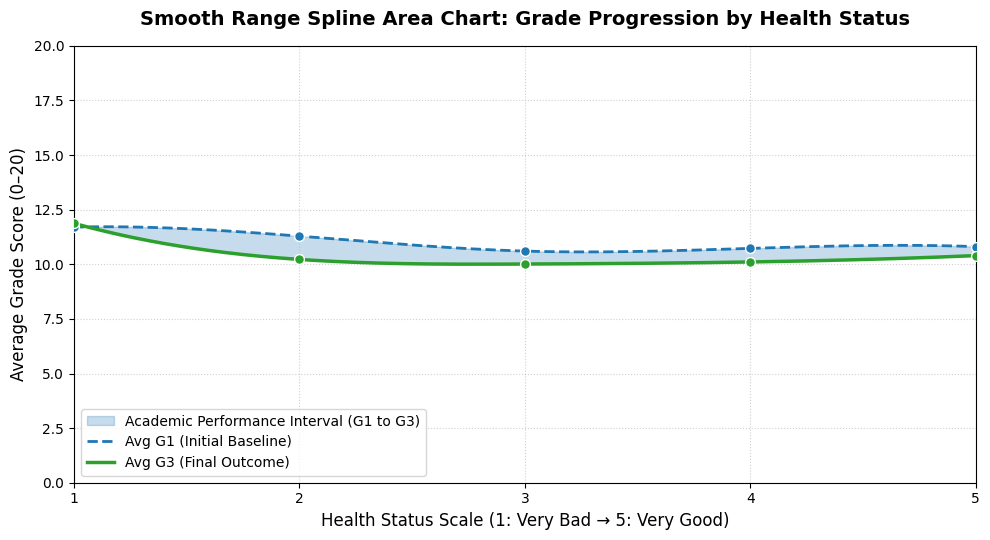

In [40]:
import matplotlib.pyplot as plt
import numpy as np
from scipy.interpolate import make_interp_spline

# 1. Aggregate lower and upper boundaries (e.g., Average G1 vs Final Grade G3) across Health Status
grouped = df.groupby('health_status').agg(
    lower_bound=('G1', 'mean'),
    upper_bound=('G3', 'mean')
).sort_index()

x = grouped.index.values
y_low = grouped['lower_bound'].values
y_high = grouped['upper_bound'].values

# 2. Generate smooth cubic spline coordinates (interpolating 300 data points between 1 and 5)
x_smooth = np.linspace(x.min(), x.max(), 300)
spline_low = make_interp_spline(x, y_low, k=3)(x_smooth)
spline_high = make_interp_spline(x, y_high, k=3)(x_smooth)

# 3. Create the plot frame
fig, ax = plt.subplots(figsize=(10, 5.5))

# 4. Fill the area range between the smooth spline lines
ax.fill_between(x_smooth, spline_low, spline_high,
                color='#1f77b4', alpha=0.25,
                label='Academic Performance Interval (G1 to G3)')

# 5. Plot the distinct boundary lines with smooth outlines
ax.plot(x_smooth, spline_low, color='#1f77b4', linewidth=2, linestyle='--', label='Avg G1 (Initial Baseline)')
ax.plot(x_smooth, spline_high, color='#2ca02c', linewidth=2.5, linestyle='-', label='Avg G3 (Final Outcome)')

# 6. Add actual point markers back on top to maintain data honesty
ax.scatter(x, y_low, color='#1f77b4', zorder=5, s=50, edgecolor='white')
ax.scatter(x, y_high, color='#2ca02c', zorder=5, s=50, edgecolor='white')

# 7. Labels, Ticks, and Cleanup
ax.set_title('Smooth Range Spline Area Chart: Grade Progression by Health Status',
             fontsize=14, fontweight='bold', pad=15)
ax.set_xlabel('Health Status Scale (1: Very Bad → 5: Very Good)', fontsize=12)
ax.set_ylabel('Average Grade Score (0–20)', fontsize=12)

ax.set_xticks(x)
ax.set_xlim(x.min(), x.max())
ax.set_ylim(0, 20)
ax.grid(True, linestyle=':', alpha=0.6)
ax.legend(loc='lower left', frameon=True)

plt.tight_layout()
plt.show()

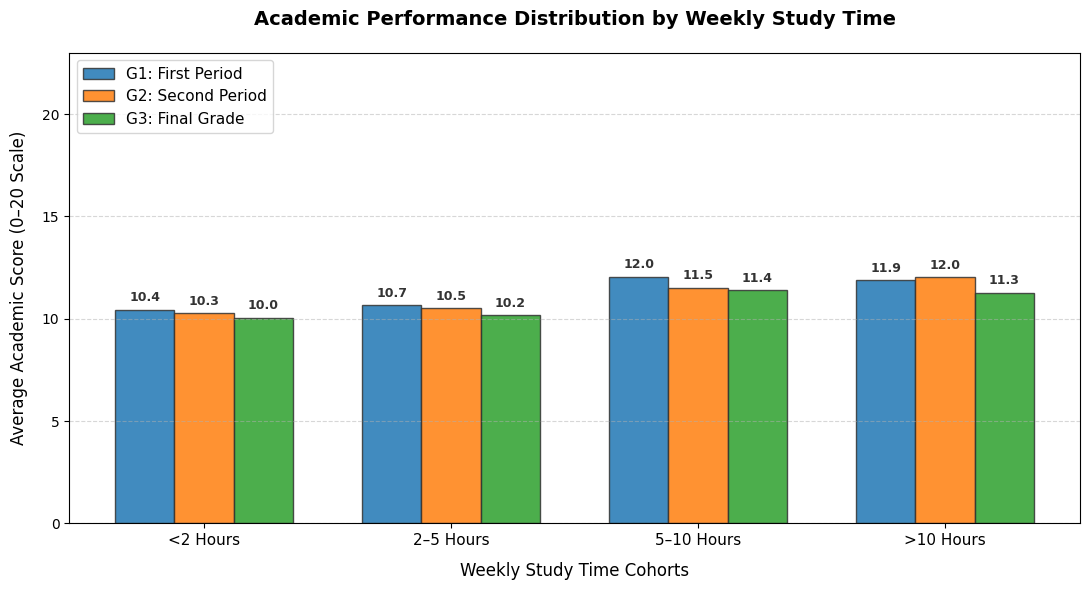

In [41]:
import matplotlib.pyplot as plt
import numpy as np

# 1. Aggregate the mean scores for G1, G2, and G3 grouped by weekly study time
grouped = df.groupby('weekly_studytime')[['G1', 'G2', 'G3']].mean().sort_index()

# Define the category names and positions along the X-axis
study_labels = ['<2 Hours', '2–5 Hours', '5–10 Hours', '>10 Hours']
x_indices = np.arange(len(study_labels))

# 2. Control the physical width of each bar and spacing
bar_width = 0.24

# 3. Set up the plotting frame
fig, ax = plt.subplots(figsize=(11, 6))

# 4. Plot each series with distinct colors and shifted horizontal offsets
bars_g1 = ax.bar(x_indices - bar_width, grouped['G1'], bar_width,
                 label='G1: First Period', color='#1f77b4', edgecolor='#333333', alpha=0.85)

bars_g2 = ax.bar(x_indices, grouped['G2'], bar_width,
                 label='G2: Second Period', color='#ff7f0e', edgecolor='#333333', alpha=0.85)

bars_g3 = ax.bar(x_indices + bar_width, grouped['G3'], bar_width,
                 label='G3: Final Grade', color='#2ca02c', edgecolor='#333333', alpha=0.85)

# 5. Helper function to attach value labels precisely on top of each individual bar
def add_value_labels(rects):
    for rect in rects:
        height = rect.get_height()
        ax.annotate(f'{height:.1f}',
                    xy=(rect.get_x() + rect.get_width() / 2, height),
                    xytext=(0, 4),  # 4 points vertical padding above the bar top
                    textcoords="offset points",
                    ha='center', va='bottom', fontsize=9, fontweight='bold', color='#333333')

# Run labeling for all three series
add_value_labels(bars_g1)
add_value_labels(bars_g2)
add_value_labels(bars_g3)

# 6. Titles, Labels, and Visual Cleanup
ax.set_title('Academic Performance Distribution by Weekly Study Time', fontsize=14, fontweight='bold', pad=20)
ax.set_xlabel('Weekly Study Time Cohorts', fontsize=12, labelpad=10)
ax.set_ylabel('Average Academic Score (0–20 Scale)', fontsize=12, labelpad=10)

# Align the custom labels to sit perfectly under each grouped block
ax.set_xticks(x_indices)
ax.set_xticklabels(study_labels, fontsize=11)

# Set the vertical limit slightly higher than 20 to leave clean buffer room for top labels
ax.set_ylim(0, 23)

# Gridlines and Legend configuration
ax.grid(axis='y', linestyle='--', alpha=0.5)
ax.legend(loc='upper left', frameon=True, fontsize=11)

plt.tight_layout()
plt.show()

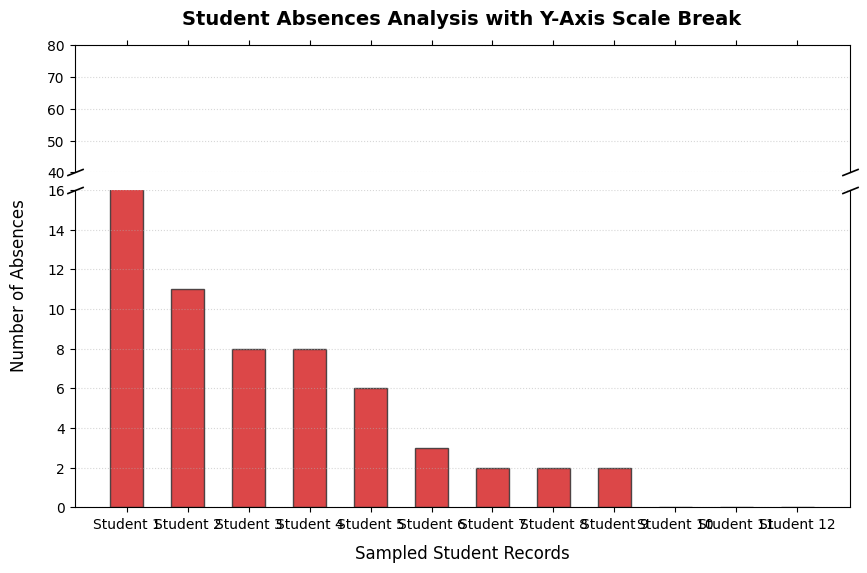

In [42]:
import matplotlib.pyplot as plt
import numpy as np

# 1. Prepare data: Let's grab a sample of 12 students showing both normal values and high outliers
# (This naturally highlights why a scale break is required)
sample_df = df.sample(12, random_state=42).copy()
sample_df = sample_df.sort_values(by='absences', ascending=False)

labels = [f'Student {i}' for i in range(1, len(sample_df) + 1)]
absences = sample_df['absences'].values

# 2. Create two stacked subplots sharing the X-axis
# 'height_ratios' allocates less vertical space to the upper outlier zone
fig, (ax1, ax2) = plt.subplots(2, 1, sharex=True, figsize=(10, 6),
                               gridspec_kw={'height_ratios': [1, 2.5]})

# Pull the two subplots close together vertically
fig.subplots_adjust(hspace=0.08)

# 3. Plot the exact same bar charts on both axes
ax1.bar(labels, absences, color='#d62728', edgecolor='#333333', alpha=0.85, width=0.55)
ax2.bar(labels, absences, color='#d62728', edgecolor='#333333', alpha=0.85, width=0.55)

# 4. Set the broken Y-axis window limits
# Top plot limits (captures extreme outliers like 40 to 80)
ax1.set_ylim(40, 80)
# Bottom plot limits (captures the normal cohort details from 0 to 16)
ax2.set_ylim(0, 16)

# 5. Hide the inner bounding spines to make it look like a single canvas
ax1.spines['bottom'].set_visible(False)
ax2.spines['top'].set_visible(False)

# Clean up tick markings between the two frames
ax1.xaxis.tick_top()
ax1.tick_params(labeltop=False)  # Turn off text labels on the very top edge
ax2.xaxis.tick_bottom()

# 6. Draw the diagonal slash markings (//) to visually signal the scale break
diagonal_length = 0.4  # Controls the angle/slanted size of the break lines
break_line_style = dict(marker=[(-1, -diagonal_length), (1, diagonal_length)], markersize=12,
                        linestyle="none", color='black', mec='black', mew=1.2, clip_on=False)

# Plot slashes on the bottom lines of the top plot and top lines of the bottom plot
ax1.plot([0, 1], [0, 0], transform=ax1.transAxes, **break_line_style)
ax2.plot([0, 1], [1, 1], transform=ax2.transAxes, **break_line_style)

# 7. Labels, Titles, and Layout Optimization
ax1.set_title('Student Absences Analysis with Y-Axis Scale Break', fontsize=14, fontweight='bold', pad=15)
ax2.set_xlabel('Sampled Student Records', fontsize=12, labelpad=10)

# Position a single shared Y-axis label centered across both subplots
ax2.set_ylabel('Number of Absences', fontsize=12)
ax2.yaxis.set_label_coords(-0.06, 0.7)

ax1.grid(axis='y', linestyle=':', alpha=0.5)
ax2.grid(axis='y', linestyle=':', alpha=0.5)

plt.show()

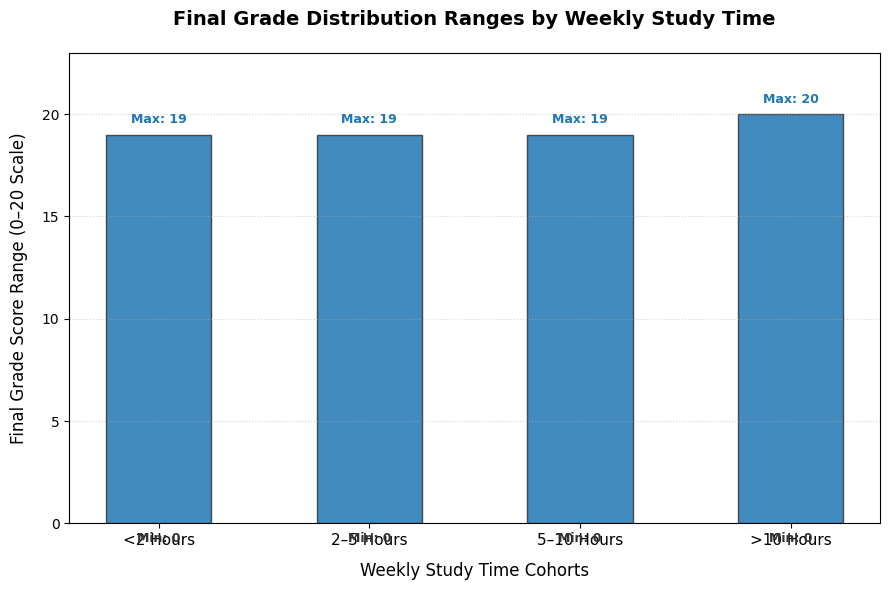

In [43]:
import matplotlib.pyplot as plt
import numpy as np

# 1. Aggregate the minimum and maximum final grades (G3) for each study time group
grouped = df.groupby('weekly_studytime')['G3'].agg(['min', 'max']).sort_index()

# Define labels and numerical positions for the X-axis
study_labels = ['<2 Hours', '2–5 Hours', '5–10 Hours', '>10 Hours']
x_indices = np.arange(len(study_labels))

# 2. Calculate the base (bottom) and the vertical length (height) of each floating column
bottom_values = grouped['min'].values
top_values = grouped['max'].values
height_intervals = top_values - bottom_values

# 3. Create the plot frame
fig, ax = plt.subplots(figsize=(9, 6))

# 4. Draw the floating columns using the 'bottom' parameter
columns = ax.bar(x_indices, height_intervals, bottom=bottom_values,
                 color='#1f77b4', edgecolor='#333333', alpha=0.85, width=0.5,
                 label='Grade Range (Min to Max)')

# 5. Add value text annotations right at the top and bottom edge of each floating bar
for rect, low, high in zip(columns, bottom_values, top_values):
    x_pos = rect.get_x() + rect.get_width() / 2

    # Label the Minimum value at the base of the column
    ax.text(x_pos, low - 0.4, f'Min: {low}',
            ha='center', va='top', fontsize=9, fontweight='bold', color='#333333')

    # Label the Maximum value at the peak of the column
    ax.text(x_pos, high + 0.4, f'Max: {high}',
            ha='center', va='bottom', fontsize=9, fontweight='bold', color='#1f77b4')

# 6. Axis Labels, Styling, and Formatting
ax.set_title('Final Grade Distribution Ranges by Weekly Study Time', fontsize=14, fontweight='bold', pad=20)
ax.set_xlabel('Weekly Study Time Cohorts', fontsize=12, labelpad=10)
ax.set_ylabel('Final Grade Score Range (0–20 Scale)', fontsize=12, labelpad=10)

# Align the custom labels to sit perfectly under each column
ax.set_xticks(x_indices)
ax.set_xticklabels(study_labels, fontsize=11)

# Set the vertical limit with a small cushion to make room for annotations
ax.set_ylim(0, 23)
ax.grid(axis='y', linestyle=':', alpha=0.5)

plt.tight_layout()
plt.show()

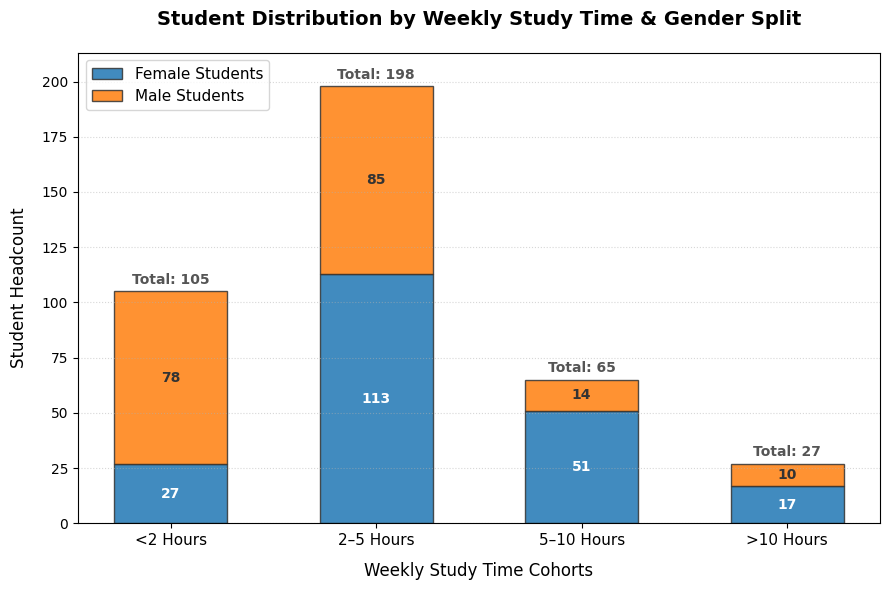

In [44]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

# 1. Create a cross-tabulation table counting students by study time and gender
# This builds a summary table with columns 'F' and 'M' and studytime as rows
pivot_df = pd.crosstab(df['weekly_studytime'], df['sex'])

# Map the category index to human-readable strings
study_labels = ['<2 Hours', '2–5 Hours', '5–10 Hours', '>10 Hours']
x_indices = np.arange(len(study_labels))

# 2. Set up the chart frame
fig, ax = plt.subplots(figsize=(9, 6))

# 3. Plot the first layer (Female cohort baseline)
bars_female = ax.bar(x_indices, pivot_df['F'], width=0.55,
                     label='Female Students', color='#1f77b4', edgecolor='#333333', alpha=0.85)

# 4. Plot the second layer (Male cohort stacked on top of Female values via the 'bottom' argument)
bars_male = ax.bar(x_indices, pivot_df['M'], width=0.55, bottom=pivot_df['F'],
                   label='Male Students', color='#ff7f0e', edgecolor='#333333', alpha=0.85)

# 5. Insert value text labels perfectly centered inside their respective stacked chunks
for idx, (f_val, m_val) in enumerate(zip(pivot_df['F'], pivot_df['M'])):
    # Label inside the lower (Female) column segment
    if f_val > 3:  # Only add label if segment is tall enough to fit text cleanly
        ax.text(idx, f_val / 2, f'{f_val}',
                ha='center', va='center', color='white', fontweight='bold', fontsize=10)

    # Label inside the upper (Male) column segment
    if m_val > 3:
        ax.text(idx, f_val + (m_val / 2), f'{m_val}',
                ha='center', va='center', color='#333333', fontweight='bold', fontsize=10)

    # Optional: Add a total cohort size label right above the complete stacked column
    total_val = f_val + m_val
    ax.text(idx, total_val + 2, f'Total: {total_val}',
            ha='center', va='bottom', fontsize=10, fontweight='bold', color='#555555')

# 6. Titles, Labels, and Theme Adjustments
ax.set_title('Student Distribution by Weekly Study Time & Gender Split', fontsize=14, fontweight='bold', pad=20)
ax.set_xlabel('Weekly Study Time Cohorts', fontsize=12, labelpad=10)
ax.set_ylabel('Student Headcount', fontsize=12, labelpad=10)

# Align the custom labels to sit perfectly under each column block
ax.set_xticks(x_indices)
ax.set_xticklabels(study_labels, fontsize=11)

# Pad the maximum vertical limit slightly above the absolute total to give labels room
max_total = (pivot_df['F'] + pivot_df['M']).max()
ax.set_ylim(0, max_total + 15)

# Add standard background gridlines and the legend frame
ax.grid(axis='y', linestyle=':', alpha=0.5)
ax.legend(loc='upper left', frameon=True, fontsize=11)

plt.tight_layout()
plt.show()

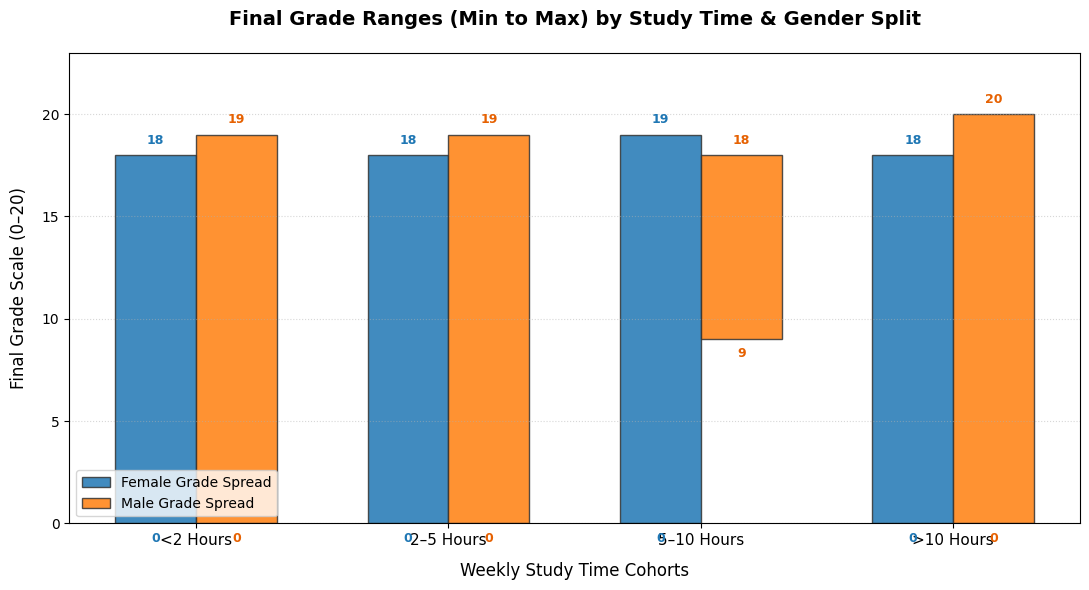

In [46]:
import matplotlib.pyplot as plt
import numpy as np

# 1. Group by both weekly study time and gender, then calculate min and max G3 grades
# .unstack() moves 'sex' from row index to multi-level column headers
grouped = df.groupby(['weekly_studytime', 'sex'])['G3'].agg(['min', 'max']).unstack()

# Define structural category dimensions
study_labels = ['<2 Hours', '2–5 Hours', '5–10 Hours', '>10 Hours']
x_indices = np.arange(len(study_labels))
bar_width = 0.32  # Thickness of each individual floating bar

# 2. Extract specific bottom and height dimensions for the female series
f_min = grouped['min']['F'].values
f_max = grouped['max']['F'].values
f_heights = f_max - f_min

# 3. Extract specific bottom and height dimensions for the male series
m_min = grouped['min']['M'].values
m_max = grouped['max']['M'].values
m_heights = m_max - m_min

# 4. Set up the plotting frame
fig, ax = plt.subplots(figsize=(11, 6))

# 5. Plot the floating bars side-by-side using precise horizontal offsets (-bar_width/2 and +bar_width/2)
bars_female = ax.bar(x_indices - bar_width/2, f_heights, bottom=f_min, width=bar_width,
                     label='Female Grade Spread', color='#1f77b4', edgecolor='#333333', alpha=0.85)

bars_male = ax.bar(x_indices + bar_width/2, m_heights, bottom=m_min, width=bar_width,
                   label='Male Grade Spread', color='#ff7f0e', edgecolor='#333333', alpha=0.85)

# 6. Helper function to label the low and high boundaries of each individual series cluster
def label_bounds(rects, low_vals, high_vals, text_color):
    for rect, low, high in zip(rects, low_vals, high_vals):
        x_pos = rect.get_x() + rect.get_width() / 2

        # Label the floor boundary (Min value)
        ax.text(x_pos, low - 0.4, f'{low}', ha='center', va='top',
                fontsize=9, color=text_color, fontweight='bold')

        # Label the ceiling boundary (Max value)
        ax.text(x_pos, high + 0.4, f'{high}', ha='center', va='bottom',
                fontsize=9, color=text_color, fontweight='bold')

# Attach labels to both floating series with matching brand colors
label_bounds(bars_female, f_min, f_max, '#1f77b4')
label_bounds(bars_male, m_min, m_max, '#e66101')

# 7. Titles, Labels, and Visual Styling
ax.set_title('Final Grade Ranges (Min to Max) by Study Time & Gender Split', fontsize=14, fontweight='bold', pad=20)
ax.set_xlabel('Weekly Study Time Cohorts', fontsize=12, labelpad=10)
ax.set_ylabel('Final Grade Scale (0–20)', fontsize=12, labelpad=10)

# Set group ticks perfectly centered under the side-by-side floating pairs
ax.set_xticks(x_indices)
ax.set_xticklabels(study_labels, fontsize=11)

# Set the vertical limit slightly higher than 20 to give headroom for the peak labels
ax.set_ylim(0, 23)
ax.grid(axis='y', linestyle=':', alpha=0.5)
ax.legend(loc='lower left', frameon=True, fontsize=10)

plt.tight_layout()
plt.show()

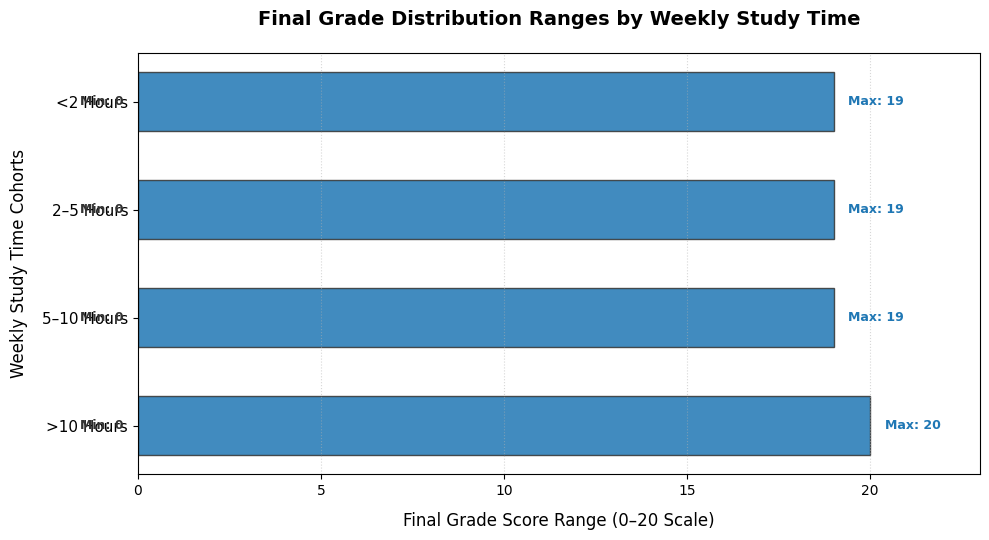

In [47]:
import matplotlib.pyplot as plt
import numpy as np

# 1. Aggregate the minimum and maximum final grades (G3) for each study time group
# We sort it descending so that the highest study time sits at the top of the chart
grouped = df.groupby('weekly_studytime')['G3'].agg(['min', 'max']).sort_index(ascending=False)

# Define labels and numerical positions along the Y-axis
study_labels = ['>10 Hours', '5–10 Hours', '2–5 Hours', '<2 Hours']
y_indices = np.arange(len(study_labels))

# 2. Calculate the base starting point (left) and horizontal length (width) of each floating bar
left_values = grouped['min'].values
right_values = grouped['max'].values
width_intervals = right_values - left_values

# 3. Set up the plotting frame
fig, ax = plt.subplots(figsize=(10, 5.5))

# 4. Draw the horizontal floating bars using the 'left' parameter
bars = ax.barh(y_indices, width_intervals, left=left_values,
                color='#1f77b4', edgecolor='#333333', alpha=0.85, height=0.55,
                label='Grade Range (Min to Max)')

# 5. Add value text annotations cleanly to the left and right sides of each floating bar
for rect, low, high in zip(bars, left_values, right_values):
    y_pos = rect.get_y() + rect.get_height() / 2

    # Label the Minimum value at the left base of the bar
    ax.text(low - 0.4, y_pos, f'Min: {low}',
            ha='right', va='center', fontsize=9, fontweight='bold', color='#333333')

    # Label the Maximum value at the right peak of the bar
    ax.text(high + 0.4, y_pos, f'Max: {high}',
            ha='left', va='center', fontsize=9, fontweight='bold', color='#1f77b4')

# 6. Axis Labels, Titles, and Theme Customization
ax.set_title('Final Grade Distribution Ranges by Weekly Study Time', fontsize=14, fontweight='bold', pad=20)
ax.set_ylabel('Weekly Study Time Cohorts', fontsize=12, labelpad=10)
ax.set_xlabel('Final Grade Score Range (0–20 Scale)', fontsize=12, labelpad=10)

# Map our categories onto the Y-axis ticks
ax.set_yticks(y_indices)
ax.set_yticklabels(study_labels, fontsize=11)

# Set the horizontal limit with a small cushion to make room for text annotations
ax.set_xlim(0, 23)
ax.grid(axis='x', linestyle=':', alpha=0.5)

plt.tight_layout()
plt.show()

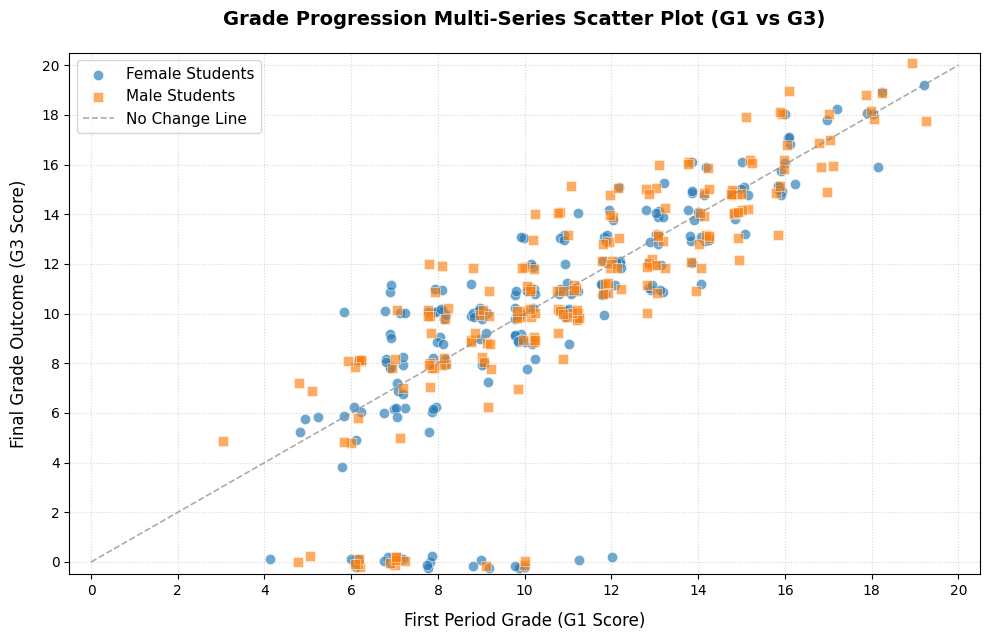

In [48]:
import matplotlib.pyplot as plt
import numpy as np

# 1. Split the dataset into distinct series (e.g., by Gender)
female_cohort = df[df['sex'] == 'F']
male_cohort = df[df['sex'] == 'M']

# 2. Set up the plotting canvas
fig, ax = plt.subplots(figsize=(10, 6.5))

# 3. Add Jittering: Since grades are whole numbers, we add a tiny bit of random noise
# to prevent dots from completely hiding behind each other (overlapping)
np.random.seed(42)  # Ensures the jitter layout is reproducible
j_fx = np.random.uniform(-0.25, 0.25, len(female_cohort))
j_fy = np.random.uniform(-0.25, 0.25, len(female_cohort))
j_mx = np.random.uniform(-0.25, 0.25, len(male_cohort))
j_my = np.random.uniform(-0.25, 0.25, len(male_cohort))

# 4. Plot each series sequentially with different markers and colors
ax.scatter(female_cohort['G1'] + j_fx, female_cohort['G3'] + j_fy,
           color='#1f77b4', s=55, alpha=0.65, edgecolors='white', linewidth=0.5,
           marker='o', label='Female Students')

ax.scatter(male_cohort['G1'] + j_mx, male_cohort['G3'] + j_my,
           color='#ff7f0e', s=55, alpha=0.65, edgecolors='white', linewidth=0.5,
           marker='s', label='Male Students')

# 5. Add a diagonal reference line (Y = X) to show who improved or declined
ax.plot([0, 20], [0, 20], color='#888888', linestyle='--', linewidth=1.2, alpha=0.7, label='No Change Line')

# 6. Axis Labels, Boundaries, and Titles
ax.set_title('Grade Progression Multi-Series Scatter Plot (G1 vs G3)', fontsize=14, fontweight='bold', pad=20)
ax.set_xlabel('First Period Grade (G1 Score)', fontsize=12, labelpad=10)
ax.set_ylabel('Final Grade Outcome (G3 Score)', fontsize=12, labelpad=10)

# Constrain the boundaries cleanly to the 0-20 academic scale
ax.set_xlim(-0.5, 20.5)
ax.set_ylim(-0.5, 20.5)
ax.set_xticks(range(0, 21, 2))
ax.set_yticks(range(0, 21, 2))

# 7. Add Grid and Legend configurations
ax.grid(True, linestyle=':', alpha=0.5)
ax.legend(loc='upper left', frameon=True, fontsize=11)

plt.tight_layout()
plt.show()

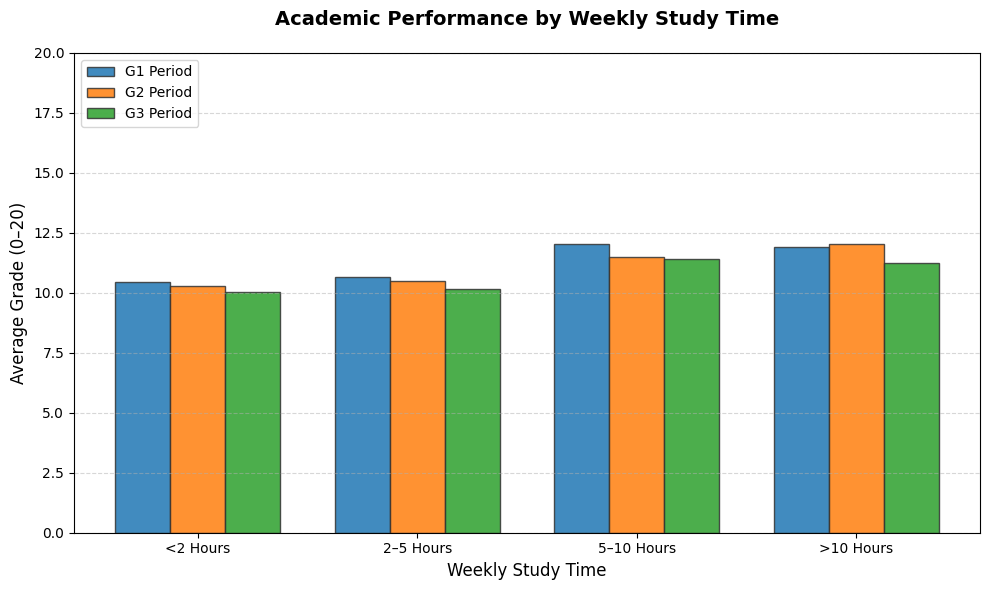

In [49]:
import matplotlib.pyplot as plt
import numpy as np

# 1. Prepare the data: Aggregate means grouped by studytime
grouped = df.groupby('weekly_studytime')[['G1', 'G2', 'G3']].mean().sort_index()

# 2. Setup labels and positioning
study_labels = ['<2 Hours', '2–5 Hours', '5–10 Hours', '>10 Hours']
x_indices = np.arange(len(study_labels))
width = 0.25  # Width of each individual bar

# 3. Create the plot
fig, ax = plt.subplots(figsize=(10, 6))

# 4. Plot each series with a horizontal offset
# The offset (x - width, x, x + width) shifts the bars side-by-side
ax.bar(x_indices - width, grouped['G1'], width, label='G1 Period', color='#1f77b4', edgecolor='#333333', alpha=0.85)
ax.bar(x_indices, grouped['G2'], width, label='G2 Period', color='#ff7f0e', edgecolor='#333333', alpha=0.85)
ax.bar(x_indices + width, grouped['G3'], width, label='G3 Period', color='#2ca02c', edgecolor='#333333', alpha=0.85)

# 5. Styling and labels
ax.set_title('Academic Performance by Weekly Study Time', fontsize=14, fontweight='bold', pad=20)
ax.set_xlabel('Weekly Study Time', fontsize=12)
ax.set_ylabel('Average Grade (0–20)', fontsize=12)
ax.set_xticks(x_indices)
ax.set_xticklabels(study_labels)
ax.set_ylim(0, 20)
ax.grid(axis='y', linestyle='--', alpha=0.5)
ax.legend(loc='upper left', frameon=True)

plt.tight_layout()
plt.show()

In [50]:
import seaborn as sns

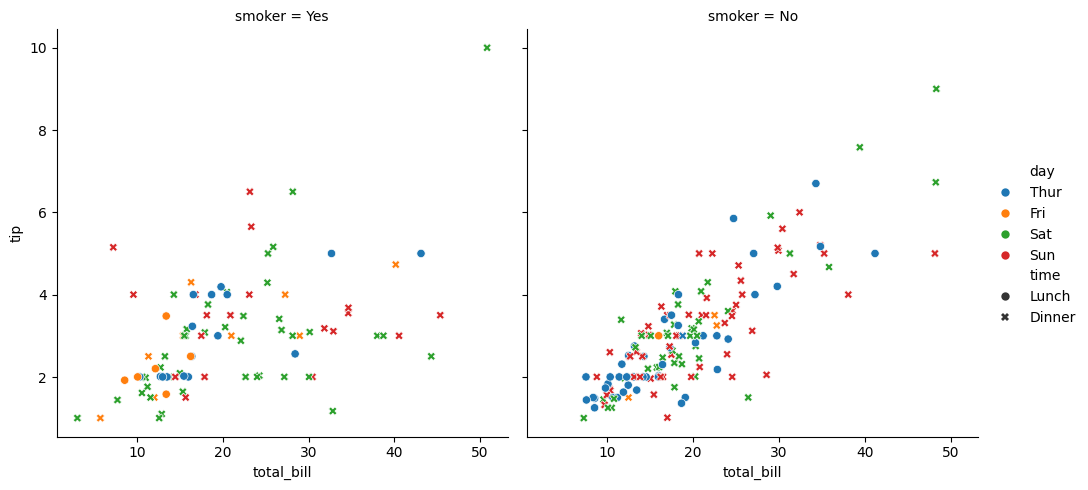

In [51]:
import seaborn as sns
import matplotlib.pyplot as plt

# Load sample data
tips = sns.load_dataset("tips")

# Figure-level plot: Scatter plot with subplots and color coding
sns.relplot(
    data=tips,
    x="total_bill", y="tip",
    hue="day", style="time",
    col="smoker", kind="scatter"
)

plt.show()


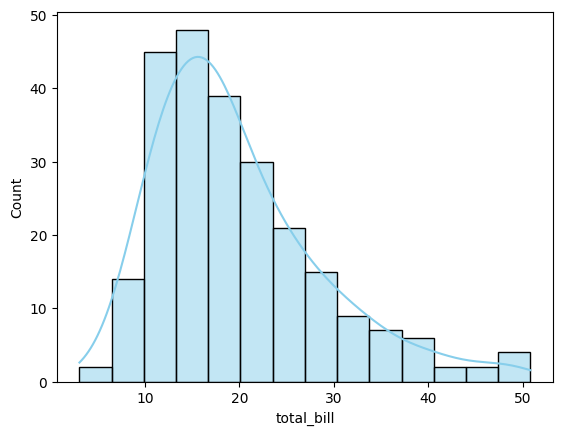

In [52]:
import seaborn as sns
import matplotlib.pyplot as plt

tips = sns.load_dataset("tips")

# Plot a histogram with a Kernel Density Estimate (KDE) curve
sns.histplot(data=tips, x="total_bill", kde=True, color="skyblue")

plt.show()


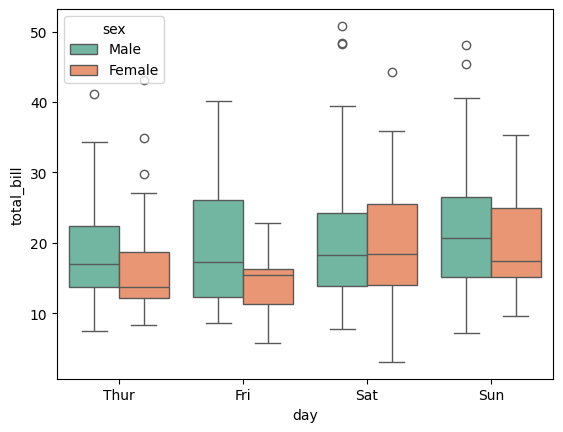

In [53]:
import seaborn as sns
import matplotlib.pyplot as plt

tips = sns.load_dataset("tips")

# Box plot to show distributions and detect outliers
sns.boxplot(data=tips, x="day", y="total_bill", hue="sex", palette="Set2")

plt.show()


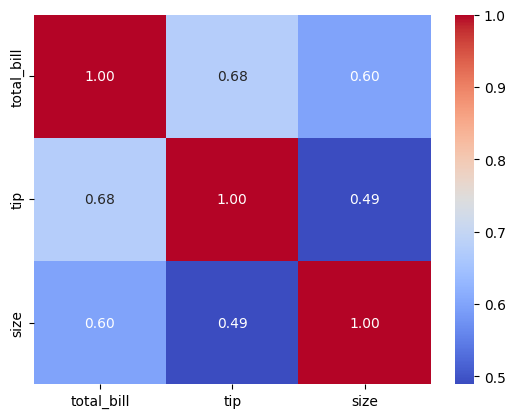

In [54]:
import seaborn as sns
import matplotlib.pyplot as plt

tips = sns.load_dataset("tips")

# Calculate correlation and display as a heatmap
corr = tips[['total_bill', 'tip', 'size']].corr()
sns.heatmap(corr, annot=True, cmap="coolwarm", fmt=".2f")

plt.show()
